In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [147]:
def get_velocity_of(path):
    data = pd.read_csv(path)
    data.dropna()

    data['U'] = np.sqrt(data['U_1']**2 + data['U_2']**2 + data['U_0']**2) # velocity magnitude
    return data

def get_velocity_pv(path):
    #return velocity for data which got from paraView
    data = pd.read_csv(path)
    data.dropna()

    data['U'] = np.sqrt(data['U:1']**2 + data_72k['U:2']**2 + data_72k['U:0']**2) # velocity magnitude
    return data

In [144]:
data_72k = pd.read_csv('channel_72k_cells_17points_05time_05location.csv')
data_72k.dropna()

data_72k['U'] = np.sqrt(data_72k['U:1']**2 + data_72k['U:2']**2 + data_72k['U:0']**2) # velocity magnitude
data_72k.head()

,p,U:0,U:1,U:2,vtkValidPointMask,arc_length,Points:0,Points:1,Points:2,U
0,0.58465,0.000000e+00,0.000000,0.00000,1,0.000000,0,-0.002261,0.05,0.00000
1,0.58466,-2.663600e-13,0.000023,0.23585,1,0.000283,0,-0.001979,0.05,0.23585
2,0.58466,-4.547500e-13,0.000068,0.44407,1,0.000565,0,-0.001696,0.05,0.44407
3,0.58466,-6.886900e-13,0.000128,0.63023,1,0.000848,0,-0.001413,0.05,0.63023
4,0.58466,-3.522100e-13,0.000176,0.78813,1,0.001131,0,-0.001131,0.05,0.78813


In [145]:
res = get_velocity_pv('channel_72k_cells_17points_05time_05location.csv')
res.head()

,p,U:0,U:1,U:2,vtkValidPointMask,arc_length,Points:0,Points:1,Points:2,U
0,0.58465,0.000000e+00,0.000000,0.00000,1,0.000000,0,-0.002261,0.05,0.00000
1,0.58466,-2.663600e-13,0.000023,0.23585,1,0.000283,0,-0.001979,0.05,0.23585
2,0.58466,-4.547500e-13,0.000068,0.44407,1,0.000565,0,-0.001696,0.05,0.44407
3,0.58466,-6.886900e-13,0.000128,0.63023,1,0.000848,0,-0.001413,0.05,0.63023
4,0.58466,-3.522100e-13,0.000176,0.78813,1,0.001131,0,-0.001131,0.05,0.78813


In [150]:
#radius
pressureGrad = 12.02186397801387
R = 0.00227 
r1 = np.linspace(-0.00227,0.00227,1000)
#data['exp']=(data['r']**2-R**2)*(1*rho/(4*1.48e-05))*pressureGrad 
data_72k['r'] = np.sqrt(data_72k['Points:0']**2 + data_72k['Points:1']**2) # array how radius changing

data_72k['exp']=(R**2-data_72k['r']**2)*(1/(4*1.48e-05))*pressureGrad 
res=(R**2-r1**2)*(1/(4*1.48e-05))*pressureGrad 

In [23]:
x2 = np.arange(0,len(data_72k),1)

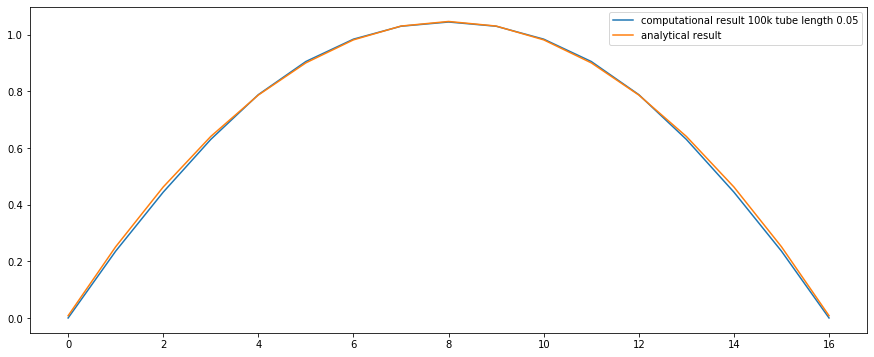

In [24]:
plt.figure(figsize=(15,6))
plt.plot(x2,data_72k['U'],label = 'computational result 72k tube at 0.05')
plt.plot(x2,data_72k['exp'], label = 'analytical result')

plt.legend(loc="upper right");

In [25]:
print('Max velocity for analytical case {:2.4}'.format(max(data_72k['exp'])))
print('Max velocity for 72k cells case {:2.4}'.format(max(data_72k['U'])))

Max velocity for analytical case 1.046
Max velocity for 72k cells case 1.044


In [33]:
data_43 = pd.read_csv('channel_72k_cells_17points_05time_043location.csv')
data_43.dropna()
data_43['U'] = np.sqrt(data_43['U:1']**2 + data_43['U:2']**2 + data_43['U:0']**2) 
data_70 = pd.read_csv('channel_72k_cells_17points_05time_07location.csv')
data_70.dropna()
data_70['U'] = np.sqrt(data_70['U:1']**2 + data_70['U:2']**2 + data_70['U:0']**2) 

data_86 = pd.read_csv('channel_72k_cells_17points_05time_043location.csv')
data_86.dropna()
data_86['U'] = np.sqrt(data_86['U:1']**2 + data_86['U:2']**2 + data_86['U:0']**2) 
data_1 = pd.read_csv('channel_72k_cells_17points_05time_1location.csv')
data_1.dropna()
data_1['U'] = np.sqrt(data_1['U:1']**2 + data_1['U:2']**2 + data_1['U:0']**2) 

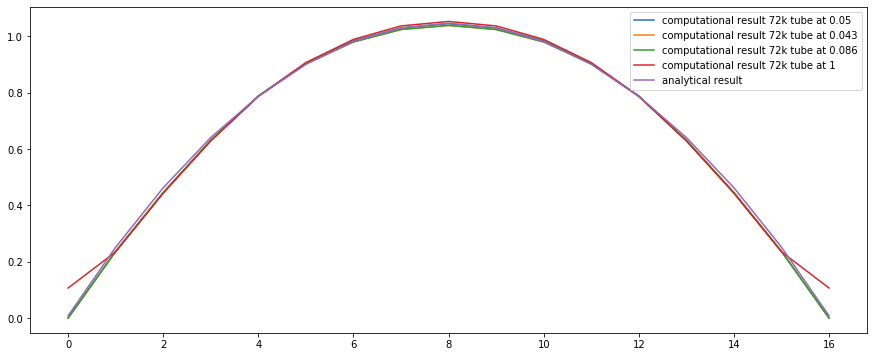

In [30]:
plt.figure(figsize=(15,6))
plt.plot(x2,data_72k['U'],label = 'computational result 72k tube at 0.05')
plt.plot(x2,data_43['U'],label = 'computational result 72k tube at 0.043')
plt.plot(x2,data_86['U'],label = 'computational result 72k tube at 0.086')
plt.plot(x2,data_1['U'],label = 'computational result 72k tube at 1')

plt.plot(x2,data_72k['exp'], label = 'analytical result')

plt.legend(loc="upper right");

In [35]:
print('Max velocity for analytical case {:2.4}'.format(max(data_72k['exp'])))
print('Max velocity for 72k cells case {:2.4}  at 0.043'.format(max(data_43['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.05'.format(max(data_72k['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.070'.format(max(data_70['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.086'.format(max(data_86['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.1'.format(max(data_1['U'])))

Max velocity for analytical case 1.046
Max velocity for 72k cells case 1.039  at 0.043
Max velocity for 72k cells case 1.044  at 0.05
Max velocity for 72k cells case 1.051  at 0.070
Max velocity for 72k cells case 1.039  at 0.086
Max velocity for 72k cells case 1.053  at 0.1


# 100k cells

# Results directly from OF

In [161]:
data_043 =get_velocity_of('sample_100k/at0.043_U.csv')

data_05 = get_velocity_of('sample_100k/at0.05_U.csv')

data_07 = get_velocity_of('sample_100k/at0.07_U.csv')

data_86 = get_velocity_of('sample_100k/at0.086_U.csv')

data_09 = get_velocity_of('sample_100k/at0.09_U.csv')

data_098 = get_velocity_of('sample_100k/at0.098_U.csv')


In [126]:
print('Max velocity for analytical case {:2.4}'.format(max(data_72k['exp'])))
print('Max velocity for 72k cells case {:2.4}  at 0.043'.format(max(data_043['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.05'.format(max(data_05['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.070'.format(max(data_07['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.086'.format(max(data_86['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.09'.format(max(data_09['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.098'.format(max(data_098['U'])))

Max velocity for analytical case 1.046
Max velocity for 72k cells case 1.054  at 0.043
Max velocity for 72k cells case 1.056  at 0.05
Max velocity for 72k cells case 1.067  at 0.070
Max velocity for 72k cells case 1.067  at 0.086
Max velocity for 72k cells case 1.067  at 0.09
Max velocity for 72k cells case 1.068  at 0.098


# Results from Paraview

In [162]:
data_043_p = get_velocity_pv('sample_100k/sample_paraView_043.csv')

data_05_p = get_velocity_pv('sample_100k/sample_paraView_05.csv')

data_07_p = get_velocity_pv('sample_100k/sample_paraView_07.csv')

data_86_p = get_velocity_pv('sample_100k/sample_paraView_086.csv')

data_09_p = get_velocity_pv('sample_100k/sample_paraView_09.csv')

data_098_p = get_velocity_pv('sample_100k/sample_paraView_98.csv')

In [163]:
print('Max velocity for analytical case {:2.4}'.format(max(data_72k['exp'])))
print('Max velocity for 100k cells case {:2.4}  at 0.043'.format(max(data_043_p['U'])))
print('Max velocity for 100k cells case {:2.4}  at 0.05'.format(max(data_05_p['U'])))
print('Max velocity for 100k cells case {:2.4}  at 0.070'.format(max(data_07_p['U'])))
print('Max velocity for 100k cells case {:2.4}  at 0.086'.format(max(data_86_p['U'])))
print('Max velocity for 100k cells case {:2.4}  at 0.09'.format(max(data_09_p['U'])))
print('Max velocity for 100k cells case {:2.4}  at 0.098'.format(max(data_098_p['U'])))

Max velocity for analytical case 1.046
Max velocity for 100k cells case 1.045  at 0.043
Max velocity for 100k cells case 1.045  at 0.05
Max velocity for 100k cells case 1.045  at 0.070
Max velocity for 100k cells case 1.045  at 0.086
Max velocity for 100k cells case 1.045  at 0.09
Max velocity for 100k cells case 1.045  at 0.098


# 45k cells

# Results from OF

In [154]:
data_043 = get_velocity_of('sample_45k/at0.043_U.csv')

data_05 = get_velocity_of('sample_45k/at0.05_U.csv')

data_07 = get_velocity_of('sample_45k/at0.07_U.csv')

data_86 = get_velocity_of('sample_45k/at0.086_U.csv')

data_09 = get_velocity_of('sample_45k/at0.09_U.csv')

data_098 = get_velocity_of('sample_45k/at0.098_U.csv')

In [155]:
print('Max velocity for analytical case {:2.4}'.format(max(data_72k['exp'])))
print('Max velocity for 72k cells case {:2.4}  at 0.043'.format(max(data_043['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.05'.format(max(data_05['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.070'.format(max(data_07['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.086'.format(max(data_86['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.09'.format(max(data_09['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.098'.format(max(data_098['U'])))

Max velocity for analytical case 1.046
Max velocity for 72k cells case 1.055  at 0.043
Max velocity for 72k cells case 1.061  at 0.05
Max velocity for 72k cells case 1.069  at 0.070
Max velocity for 72k cells case 1.07  at 0.086
Max velocity for 72k cells case 1.07  at 0.09
Max velocity for 72k cells case 1.07  at 0.098


# 73k cells

# Results from OF

In [156]:
data_043 = get_velocity_of('sample_73k/at0.043_U.csv')

data_05 = get_velocity_of('sample_73k/at0.05_U.csv')

data_07 = get_velocity_of('sample_73k/at0.07_U.csv')

data_86 = get_velocity_of('sample_73k/at0.086_U.csv')

data_09 = get_velocity_of('sample_73k/at0.09_U.csv')

data_098 = get_velocity_of('sample_73k/at0.098_U.csv')

print('Max velocity for analytical case {:2.4}'.format(max(data_72k['exp'])))
print('Max velocity for 72k cells case {:2.4}  at 0.043'.format(max(data_043['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.05'.format(max(data_05['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.070'.format(max(data_07['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.086'.format(max(data_86['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.09'.format(max(data_09['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.098'.format(max(data_098['U'])))

Max velocity for analytical case 1.046
Max velocity for 72k cells case 1.054  at 0.043
Max velocity for 72k cells case 1.056  at 0.05
Max velocity for 72k cells case 1.067  at 0.070
Max velocity for 72k cells case 1.067  at 0.086
Max velocity for 72k cells case 1.067  at 0.09
Max velocity for 72k cells case 1.065  at 0.098


# 249 cells

# Results from OF

In [157]:
data_043 = get_velocity_of('sample_249k/at0.043_U.csv')

data_05 = get_velocity_of('sample_249k/at0.05_U.csv')

data_07 = get_velocity_of('sample_249k/at0.07_U.csv')

data_86 = get_velocity_of('sample_249k/at0.086_U.csv')

data_09 = get_velocity_of('sample_249k/at0.09_U.csv')

data_098 = get_velocity_of('sample_249k/at0.098_U.csv')


print('Max velocity for analytical case {:2.4}'.format(max(data_72k['exp'])))
print('Max velocity for 72k cells case {:2.4}  at 0.043'.format(max(data_043['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.05'.format(max(data_05['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.070'.format(max(data_07['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.086'.format(max(data_86['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.09'.format(max(data_09['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.098'.format(max(data_098['U'])))

Max velocity for analytical case 1.046
Max velocity for 72k cells case 1.056  at 0.043
Max velocity for 72k cells case 1.062  at 0.05
Max velocity for 72k cells case 1.069  at 0.070
Max velocity for 72k cells case 1.07  at 0.086
Max velocity for 72k cells case 1.071  at 0.09
Max velocity for 72k cells case 1.07  at 0.098


# Length 2m, 90k cells, OF

In [158]:
data_043 = get_velocity_of('sample_90k_l2/at0.043_U.csv')

data_05 = get_velocity_of('sample_90k_l2/at0.05_U.csv')

data_07 = get_velocity_of('sample_90k_l2/at0.07_U.csv')

data_86 = get_velocity_of('sample_90k_l2/at0.086_U.csv')

data_09 = get_velocity_of('sample_90k_l2/at0.09_U.csv')

data_098 = get_velocity_of('sample_90k_l2/at0.098_U.csv')

data_12 = get_velocity_of('sample_90k_l2/at0.12_U.csv')

data_15 = get_velocity_of('sample_90k_l2/at0.15_U.csv')

data_17 = get_velocity_of('sample_90k_l2/at0.17_U.csv')

data_19 = get_velocity_of('sample_90k_l2/at0.19_U.csv')


print('Max velocity for analytical case {:2.4}'.format(max(data_72k['exp'])))
print('Max velocity for 72k cells case {:2.4}  at 0.043'.format(max(data_043['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.05'.format(max(data_05['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.070'.format(max(data_07['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.086'.format(max(data_86['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.09'.format(max(data_09['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.098'.format(max(data_098['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.12'.format(max(data_12['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.15'.format(max(data_15['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.17'.format(max(data_17['U'])))
print('Max velocity for 72k cells case {:2.4}  at 0.19'.format(max(data_19['U'])))

Max velocity for analytical case 1.046
Max velocity for 72k cells case 1.055  at 0.043
Max velocity for 72k cells case 1.061  at 0.05
Max velocity for 72k cells case 1.069  at 0.070
Max velocity for 72k cells case 1.07  at 0.086
Max velocity for 72k cells case 1.07  at 0.09
Max velocity for 72k cells case 1.07  at 0.098
Max velocity for 72k cells case 1.07  at 0.12
Max velocity for 72k cells case 1.071  at 0.15
Max velocity for 72k cells case 1.071  at 0.17
Max velocity for 72k cells case 1.071  at 0.19


# 144k cells length 2m

In [159]:
data_043 = get_velocity_of('sample_144k_l2/at0.043_U.csv')

data_05 = get_velocity_of('sample_144k_l2/at0.05_U.csv')

data_07 = get_velocity_of('sample_144k_l2/at0.07_U.csv')

data_86 = get_velocity_of('sample_144k_l2/at0.086_U.csv')

data_09 = get_velocity_of('sample_144k_l2/at0.09_U.csv')

data_098 = get_velocity_of('sample_144k_l2/at0.098_U.csv')

data_12 = get_velocity_of('sample_144k_l2/at0.12_U.csv')

data_15 = get_velocity_of('sample_144k_l2/at0.15_U.csv')

data_17 = get_velocity_of('sample_144k_l2/at0.17_U.csv')

data_19 = get_velocity_of('sample_144k_l2/at0.19_U.csv')

print('Max velocity for analytical case {:2.4}'.format(max(data_72k['exp'])))
print('Max velocity for 144k cells case {:2.4}  at 0.043'.format(max(data_043['U'])))
print('Max velocity for 144k cells case {:2.4}  at 0.05'.format(max(data_05['U'])))
print('Max velocity for 144k cells case {:2.4}  at 0.070'.format(max(data_07['U'])))
print('Max velocity for 144k cells case {:2.4}  at 0.086'.format(max(data_86['U'])))
print('Max velocity for 144k cells case {:2.4}  at 0.09'.format(max(data_09['U'])))
print('Max velocity for 144k cells case {:2.4}  at 0.098'.format(max(data_098['U'])))
print('Max velocity for 144k cells case {:2.4}  at 0.12'.format(max(data_12['U'])))
print('Max velocity for 144k cells case {:2.4}  at 0.15'.format(max(data_15['U'])))
print('Max velocity for 144k cells case {:2.4}  at 0.17'.format(max(data_17['U'])))
print('Max velocity for 144k cells case {:2.4}  at 0.19'.format(max(data_19['U'])))

Max velocity for analytical case 1.046
Max velocity for 144k cells case 1.054  at 0.043
Max velocity for 144k cells case 1.058  at 0.05
Max velocity for 144k cells case 1.067  at 0.070
Max velocity for 144k cells case 1.065  at 0.086
Max velocity for 144k cells case 1.067  at 0.09
Max velocity for 144k cells case 1.064  at 0.098
Max velocity for 144k cells case 1.068  at 0.12
Max velocity for 144k cells case 1.068  at 0.15
Max velocity for 144k cells case 1.066  at 0.17
Max velocity for 144k cells case 1.067  at 0.19
